In [1]:
import pandas as pd
import numpy as np

import os
import sys

sys.path.append('..')
from scripts import DG_at_T

In [2]:
files = os.listdir("./leave_one_out_results/")

dfs = []
for file in files:
    name = file.split("_")[1]
    df = pd.read_csv(f"./leave_one_out_results/{file}")
    df["Name"] = name
    dfs.append(df)  

df_loo = pd.concat(dfs, ignore_index=True)
# Leave only one every four rows (delta Cp), starting from the third row (index 2)
df_loo_cp = df_loo.iloc[2::4, :].reset_index(drop=True)


# Remove P6A because the unfolded baseline is not present
# and there is a big discrepancy between the first and second best models
df_loo_cp = df_loo_cp[df_loo_cp["Name"] != "P6A"].reset_index(drop=True)

df_loo_cp.head()

,Parameter,Leave_one_out_mean,Leave_one_out_std,N fits,Name
0,ΔCp (kcal / mol / K),0.826846,0.042383,19,P2A
1,ΔCp (kcal / mol / K),0.861133,0.013476,23,G4A
2,ΔCp (kcal / mol / K),0.847004,0.049051,20,P5B
3,ΔCp (kcal / mol / K),0.937740,0.034897,21,A4B
4,ΔCp (kcal / mol / K),1.108481,0.198229,18,G6B


In [3]:
df_residues = pd.read_csv("./residues.txt",sep=',')
# Convert Residue to expected delta Cp according to the size: =0.0142*NRES+0.0025
df_residues["Expected_delta_Cp"] = 0.0142*df_residues["Residues"] + 0.0025
df_residues.head()

,Name,Residues,Expected_delta_Cp
0,G4B,105,1.4935
1,P5A,200,2.8425
2,G8A,111,1.5787
3,P6B,179,2.5443
4,P3B,168,2.3881


In [4]:
# Join the two dataframes on the "Name" column
df_joined = pd.merge(df_loo_cp, df_residues, on="Name")
df_joined.head()

,Parameter,Leave_one_out_mean,Leave_one_out_std,N fits,Name,Residues,Expected_delta_Cp
0,ΔCp (kcal / mol / K),0.826846,0.042383,19,P2A,104,1.4793
1,ΔCp (kcal / mol / K),0.861133,0.013476,23,G4A,105,1.4935
2,ΔCp (kcal / mol / K),0.847004,0.049051,20,P5B,200,2.8425
3,ΔCp (kcal / mol / K),0.937740,0.034897,21,A4B,139,1.9763
4,ΔCp (kcal / mol / K),1.108481,0.198229,18,G6B,107,1.5219


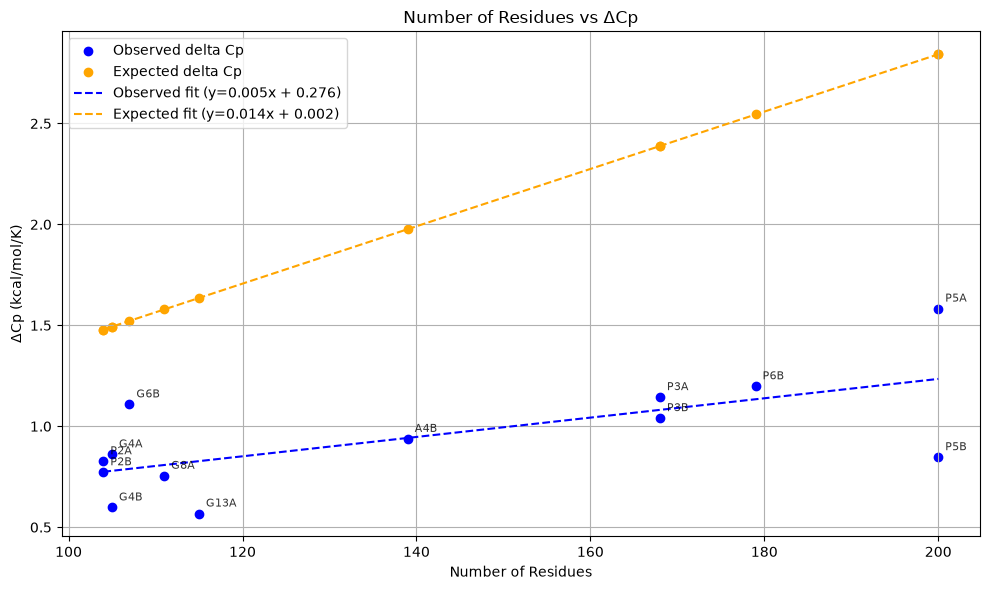

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plots
plt.scatter(
    df_joined["Residues"],
    df_joined["Leave_one_out_mean"],
    label="Observed delta Cp",
    color="blue"
)

plt.scatter(
    df_joined["Residues"],
    df_joined["Expected_delta_Cp"],
    label="Expected delta Cp",
    color="orange"
)

# Linear fits
x = df_joined["Residues"]

# Observed fit
m_obs, b_obs = np.polyfit(x, df_joined["Leave_one_out_mean"], 1)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit_obs = m_obs * x_fit + b_obs

plt.plot(
    x_fit,
    y_fit_obs,
    color="blue",
    linestyle="--",
    label=f"Observed fit (y={m_obs:.3f}x + {b_obs:.3f})"
)

# Expected fit
m_exp, b_exp = np.polyfit(x, df_joined["Expected_delta_Cp"], 1)
y_fit_exp = m_exp * x_fit + b_exp

plt.plot(
    x_fit,
    y_fit_exp,
    color="orange",
    linestyle="--",
    label=f"Expected fit (y={m_exp:.3f}x + {b_exp:.3f})"
)

# Add labels to observed points
for _, row in df_joined.iterrows():
    plt.annotate(
        row["Name"],
        (row["Residues"], row["Leave_one_out_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Number of Residues")
plt.ylabel("ΔCp (kcal/mol/K)")
plt.title("Number of Residues vs ΔCp")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [6]:

comparison_files = os.listdir("./comparison_tables/")
dfs = []
for file in comparison_files:
    name = file.split("_")[1]
    df = pd.read_csv(f"./comparison_tables/{file}")
    # Keep only first row, first three columns
    df = df.iloc[0:1, 1:3]
    df["Name"] = name
    dfs.append(df)

df_comparison = pd.concat(dfs, ignore_index=True)
df_comparison.head()

,Native Baseline,Unfolded Baseline,Name
0,quadratic,quadratic,G13A
1,exponential,quadratic,P2B
2,quadratic,linear,A4B
3,quadratic,linear,P3A
4,quadratic,quadratic,G4A


In [7]:
import pandas as pd

# Pivot means and stds
means = df_loo.pivot(
    index="Name",
    columns="Parameter",
    values="Leave_one_out_mean"
)

stds = df_loo.pivot(
    index="Name",
    columns="Parameter",
    values="Leave_one_out_std"
)

# Build output dataframe
out = pd.DataFrame(index=means.index)

parameters = [
    "Tm (°C)",
    "ΔHm (kcal / mol)",
    "ΔCp (kcal / mol / K)",
    "m-value (kcal / mol / M)"
]

for p in parameters:
    out[p] = (
        means[p].round(2).map("{:.2f}".format)
        + " ± "
        + stds[p].round(2).map("{:.2f}".format)
    )

# Rank according to Tm mean (highest Tm = rank 1)
out["Rank"] = (
    means["Tm (°C)"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Final layout
out = (
    out.reset_index()
       [["Rank", "Name"] + parameters]
       .sort_values("Rank")
       .reset_index(drop=True)
)

out.head()

,Rank,Name,Tm (°C),ΔHm (kcal / mol),ΔCp (kcal / mol / K),m-value (kcal / mol / M)
0,1,P5A,173.70 ± 1.99,229.49 ± 4.92,1.58 ± 0.04,5.66 ± 0.17
1,2,G4B,149.60 ± 1.21,76.41 ± 0.77,0.60 ± 0.01,1.51 ± 0.03
2,3,G8A,141.25 ± 2.65,88.46 ± 4.21,0.75 ± 0.06,2.26 ± 0.07
3,4,P6B,136.79 ± 0.36,153.70 ± 1.07,1.20 ± 0.02,3.34 ± 0.03
4,5,P6A,130.36 ± 0.57,211.68 ± 6.26,2.42 ± 0.09,3.17 ± 0.07


In [8]:
# Now we create a results table as follows
# Rank, Name, Tm, ΔHm, ΔCp, m-value, native_baseline_equation, unfolded_baseline_equation
joined_df = pd.merge(out, df_comparison, on="Name")

# Remove P6A because the unfolded baseline is not present
# and there is a big discrepancy between the first and second best models
joined_df = joined_df[joined_df["Name"] != "P6A"].reset_index(drop=True)

joined_df.head(15)

# G5A is not here because the fitting failed

,Rank,Name,Tm (°C),ΔHm (kcal / mol),ΔCp (kcal / mol / K),m-value (kcal / mol / M),Native Baseline,Unfolded Baseline
0,1,P5A,173.70 ± 1.99,229.49 ± 4.92,1.58 ± 0.04,5.66 ± 0.17,quadratic,linear
1,2,G4B,149.60 ± 1.21,76.41 ± 0.77,0.60 ± 0.01,1.51 ± 0.03,linear,linear
2,3,G8A,141.25 ± 2.65,88.46 ± 4.21,0.75 ± 0.06,2.26 ± 0.07,exponential,exponential
3,4,P6B,136.79 ± 0.36,153.70 ± 1.07,1.20 ± 0.02,3.34 ± 0.03,quadratic,linear
4,6,P3B,127.72 ± 0.38,113.54 ± 2.10,1.04 ± 0.02,2.44 ± 0.04,quadratic,linear
5,7,G4A,127.14 ± 0.26,96.42 ± 1.31,0.86 ± 0.01,2.40 ± 0.03,quadratic,quadratic
6,8,P3A,125.87 ± 0.17,116.59 ± 0.94,1.14 ± 0.01,2.63 ± 0.02,quadratic,linear
7,9,A4B,115.00 ± 0.65,92.79 ± 3.26,0.94 ± 0.03,1.93 ± 0.07,quadratic,linear
8,10,P5B,113.68 ± 0.98,83.24 ± 4.51,0.85 ± 0.05,2.12 ± 0.11,quadratic,linear
9,11,G6B,112.27 ± 1.22,99.64 ± 15.95,1.11 ± 0.20,1.97 ± 0.33,exponential,quadratic


In [9]:
# Obtain the average Tm
tm_values = joined_df["Tm (°C)"].values
tm_values = [float(tm.split(" ± ")[0]) for tm in tm_values]
tm_average = np.mean(tm_values)
tm_average

np.float64(125.31384615384614)

In [10]:
# Do linear fit of delta Cp vs m-value
delta_cp_values = joined_df["ΔCp (kcal / mol / K)"].values
delta_cp_values = [float(cp.split(" ± ")[0]) for cp in delta_cp_values]

m_values = joined_df["m-value (kcal / mol / M)"].values
m_values = [float(m.split(" ± ")[0]) for m in m_values]

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(m_values, delta_cp_values)
print(slope) # Shown in Figure 6, panel A of the manuscript

0.21605371313216934


In [11]:
# Obtain the DG versus temperature curves for all the proteins and plot them together
temperature_range = np.arange(273.15, 423.15, 0.1)  # From 0°C to 150°C in Kelvin

dfs = []
for i, row in joined_df.iterrows():

    dh = float(row["ΔHm (kcal / mol)"].split(" ± ")[0])
    tm = float(row["Tm (°C)"].split(" ± ")[0]) 
    cp = float(row["ΔCp (kcal / mol / K)"].split(" ± ")[0])

    dg = DG_at_T(temperature_range, tm, cp,dh)  # Convert Tm to Kelvin

    name = row["Name"]
    n_res = df_residues[df_residues["Name"] == name]["Residues"].values[0]

    # Make name a combination of name and number of residues
    name = f"{name} ({n_res} residues)"

    df = pd.DataFrame({
        "Temperature (K)": temperature_range,
        "ΔG (kcal/mol)": dg,
        "Name": name
    })
    dfs.append(df)


df_dg = pd.concat(dfs, ignore_index=True)

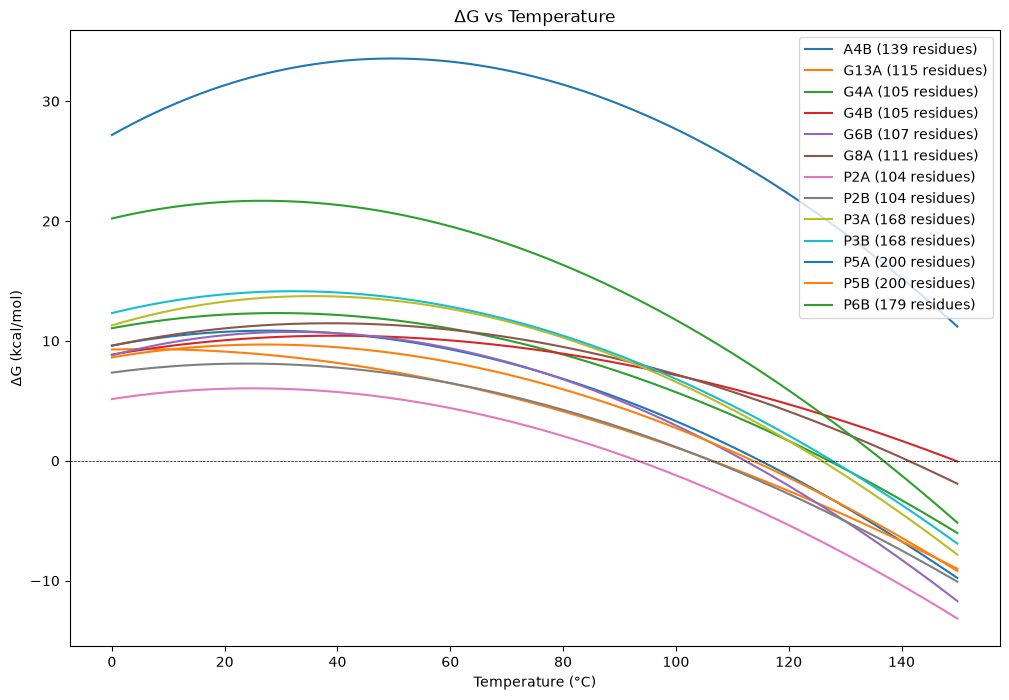

In [12]:
# Plotting the ΔG vs Temperature in degree celsius curves for all proteins
plt.figure(figsize=(12, 8))
for name, group in df_dg.groupby("Name"):
    plt.plot(group["Temperature (K)"] - 273.15, group["ΔG (kcal/mol)"], label=name)
plt.xlabel("Temperature (°C)")
plt.ylabel("ΔG (kcal/mol)")
plt.title("ΔG vs Temperature")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()
# Save the figure
plt.savefig("./figures/dg_vs_temperature_all_proteins.png", dpi=300)